In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [2]:
forex_data = pd.read_csv("Technical_Data/forex_with_indicators.csv")

In [3]:
forex_data["DateTime"] = pd.to_datetime(forex_data["DateTime"])

In [4]:
forex_data = forex_data.dropna().reset_index(drop=True)

In [5]:
forex_data.head()

,DateTime,PairID,PairName,Open,High,Low,Close,Volume,Spread,SMA_10,SMA_20,EMA_10,RSI,MACD,Signal_Line,Middle_Band,Upper_Band,Lower_Band
0,2023-01-01 19:00:00,1,EUR/USD,1.07828,1.07864,1.07773,1.07863,1814,0.8,1.079686,1.080104,1.079611,41.488020,-0.000338,-0.000168,1.080104,1.081732,1.078476
1,2023-01-01 20:00:00,1,EUR/USD,1.07879,1.08002,1.07859,1.07869,2929,2.0,1.079629,1.080011,1.079443,34.647887,-0.000394,-0.000213,1.080011,1.081742,1.078281
2,2023-01-01 21:00:00,1,EUR/USD,1.07718,1.07785,1.07681,1.07743,4387,1.7,1.079466,1.079869,1.079077,27.607362,-0.000534,-0.000277,1.079869,1.081942,1.077796
3,2023-01-01 22:00:00,1,EUR/USD,1.07965,1.07970,1.07863,1.07895,1816,0.8,1.079416,1.079789,1.079054,41.112323,-0.000516,-0.000325,1.079789,1.081876,1.077703
4,2023-01-01 23:00:00,1,EUR/USD,1.07834,1.07925,1.07786,1.07833,2483,1.1,1.079135,1.079662,1.078922,40.191898,-0.000546,-0.000369,1.079662,1.081779,1.077545


In [6]:
forex_data["Action"] = "HOLD"

In [7]:
forex_data["Reward"] = 0.0

In [8]:
for i in range(1, len(forex_data)):
    
    if forex_data.loc[i, "SMA_10"] > forex_data.loc[i, "SMA_20"]:
        forex_data.loc[i, "Action"] = "BUY"

    elif forex_data.loc[i, "SMA_10"] < forex_data.loc[i, "SMA_20"]:
        forex_data.loc[i, "Action"] = "SELL"

    else:
        forex_data.loc[i, "Action"] = "HOLD"

In [9]:
for i in range(len(forex_data) - 1):
    
    current_price = forex_data.loc[i, "Close"]

    next_price = forex_data.loc[i + 1, "Close"]

    if forex_data.loc[i, "Action"] == "BUY":
        forex_data.loc[i, "Reward"] = next_price - current_price

    elif forex_data.loc[i, "Action"] == "SELL":
        forex_data.loc[i, "Reward"] = current_price - next_price

    else:
        forex_data.loc[i, "Reward"] = 0

In [10]:
total_reward = forex_data["Reward"].sum()

print("Total Reward:", total_reward)

Total Reward: 0.008880000000000887


In [11]:
print(forex_data["Action"].value_counts())

Action
BUY     316
SELL    164
HOLD      1
Name: count, dtype: int64


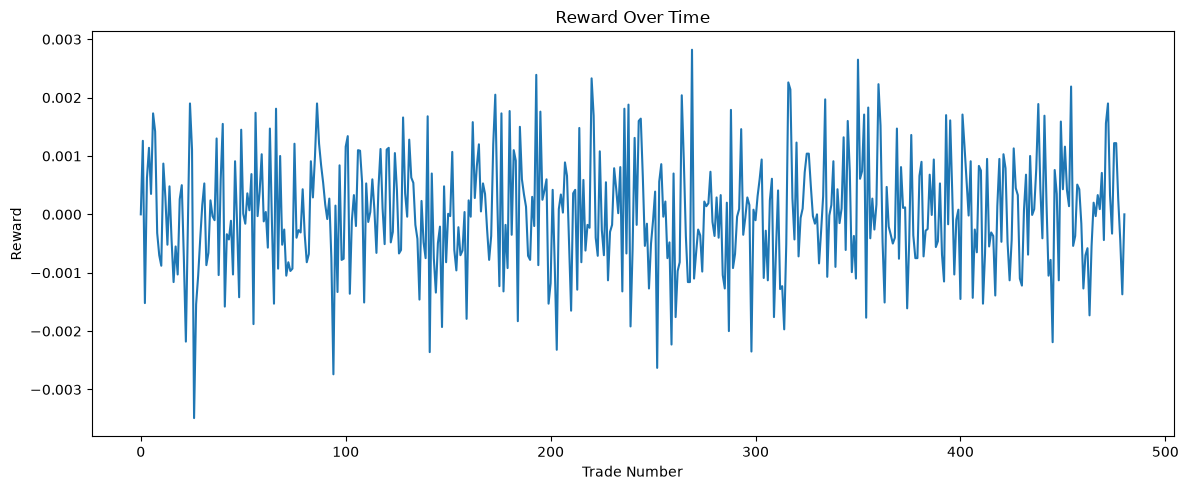

In [12]:
plt.figure(figsize=(12,5))

plt.plot(forex_data["Reward"])

plt.title("Reward Over Time")

plt.xlabel("Trade Number")

plt.ylabel("Reward")

plt.tight_layout()

plt.show()

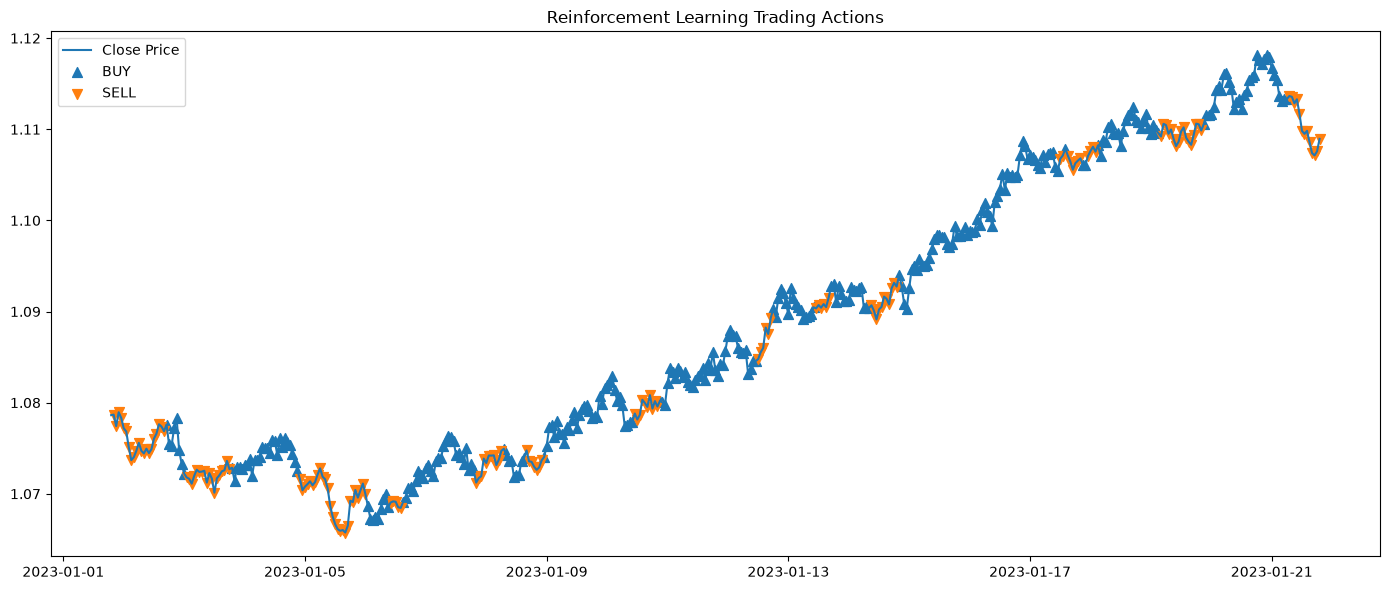

In [13]:
plt.figure(figsize=(14,6))

plt.plot(
    forex_data["DateTime"],
    forex_data["Close"],
    label="Close Price"
)

buy = forex_data[forex_data["Action"] == "BUY"]
sell = forex_data[forex_data["Action"] == "SELL"]

plt.scatter(
    buy["DateTime"],
    buy["Close"],
    marker="^",
    s=50,
    label="BUY"
)

plt.scatter(
    sell["DateTime"],
    sell["Close"],
    marker="v",
    s=50,
    label="SELL"
)

plt.legend()

plt.title("Reinforcement Learning Trading Actions")

plt.tight_layout()

plt.show()

In [15]:
forex_data.to_csv(
    "Reinforcement_Learning/rl_results.csv",
    index=False
)

In [17]:
import os

print(os.listdir("Reinforcement_Learning"))

['rl_results.csv']
